# Fig. 9 Modality-Specific OOD Sweeps

This notebook renders the OOD tests where one modality stays at the training corruption probability and the other modality is swept.

- Fig. 9a (CDM): keep text probability $p_t=0.20$ and vary image probability $p_i$.
- Fig. 9b (VLM): keep image probability $p_i=0.20$ and vary text probability $p_t$.

The inputs are generated by `figures/eval-cdm-ood.py` and `figures/eval-vlm-ood.py`.

In [1]:
# Import plotting and data-loading utilities used throughout the figure notebooks.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("./data/ghm-data")
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use the same serif/mathtext styling as the other paper figure notebooks.
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# Keep model colors synchronized with the Fig. 8 OOD plots.
COLORS = {
    "Bayes": "maroon",
    "Mis-spec. BP": "black",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
    "Joint Training": "purple",
}
RUN_TYPES = list(COLORS.keys())

In [2]:
def load_ood_json(filename):
    """Read one OOD result JSON and verify that all plotted series exist."""
    path = DATA_DIR / filename
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    required_keys = ["p_flip", *RUN_TYPES]
    missing = [key for key in required_keys if key not in data]
    if missing:
        raise KeyError(f"{path} is missing required series: {missing}")
    return data


def plot_modality_sweep(data, output_name, xlabel, risk_ylim, excess_ylim, legend_fontsize=8):
    """Plot risk and excess-risk curves for one fixed-modality OOD sweep."""
    fig, ax1 = plt.subplots(figsize=(5, 4), dpi=300)

    # Convert percent-valued JSON p values, e.g. 20, into plot-scale probabilities.
    p_flip = np.asarray(data["p_flip"], dtype=float) / 100.0
    for model_type in RUN_TYPES:
        ax1.plot(
            p_flip,
            data[model_type],
            label=model_type,
            color=COLORS[model_type],
            linewidth=2,
            marker="o",
            markersize=2,
            alpha=0.7,
        )

    ax1.set_xlabel(xlabel, fontsize=12)
    ax1.set_ylabel(r"Risk", color="navy", fontsize=12)
    ax1.tick_params(axis="y", labelcolor="navy")
    ax1.grid(True, ls="--", alpha=0.5)
    ax1.set_ylim(*risk_ylim)

    # The right axis shows each method's nonnegative excess over Bayes risk.
    ax2 = ax1.twinx()
    y_bayes = np.asarray(data["Bayes"], dtype=float)
    for model_type in RUN_TYPES[1:]:
        y_model = np.asarray(data[model_type], dtype=float)
        ax2.plot(
            p_flip,
            np.maximum(0, y_model - y_bayes),
            label="_nolegend_",
            color=COLORS[model_type],
            linestyle="--",
            linewidth=2,
        )

    # Right-axis formatting and combined legend entries.
    ax2.set_ylabel(r"Excess risk", color="brown", fontsize=12)
    ax2.tick_params(axis="y", labelcolor="brown")
    ax2.set_ylim(*excess_ylim)
    legend_lines = [ax1.get_lines()[idx] for idx in range(len(RUN_TYPES))]
    legend_labels = RUN_TYPES.copy()
    legend_lines.append(plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk"))
    legend_labels.append("Excess risk")
    legend = ax1.legend(
        legend_lines,
        legend_labels,
        loc="upper left",
        frameon=True,
        fancybox=True,
        framealpha=1,
        facecolor="white",
        edgecolor="black",
        fontsize=legend_fontsize,
    )
    legend.get_frame().set_linewidth(1.0)

    fig.savefig(OUTPUT_DIR / output_name, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Fig. 9a: CDM, fixed text probability

CDM keeps the text-side probability fixed at $p_t=0.20$ and sweeps the image-side probability $p_i$.

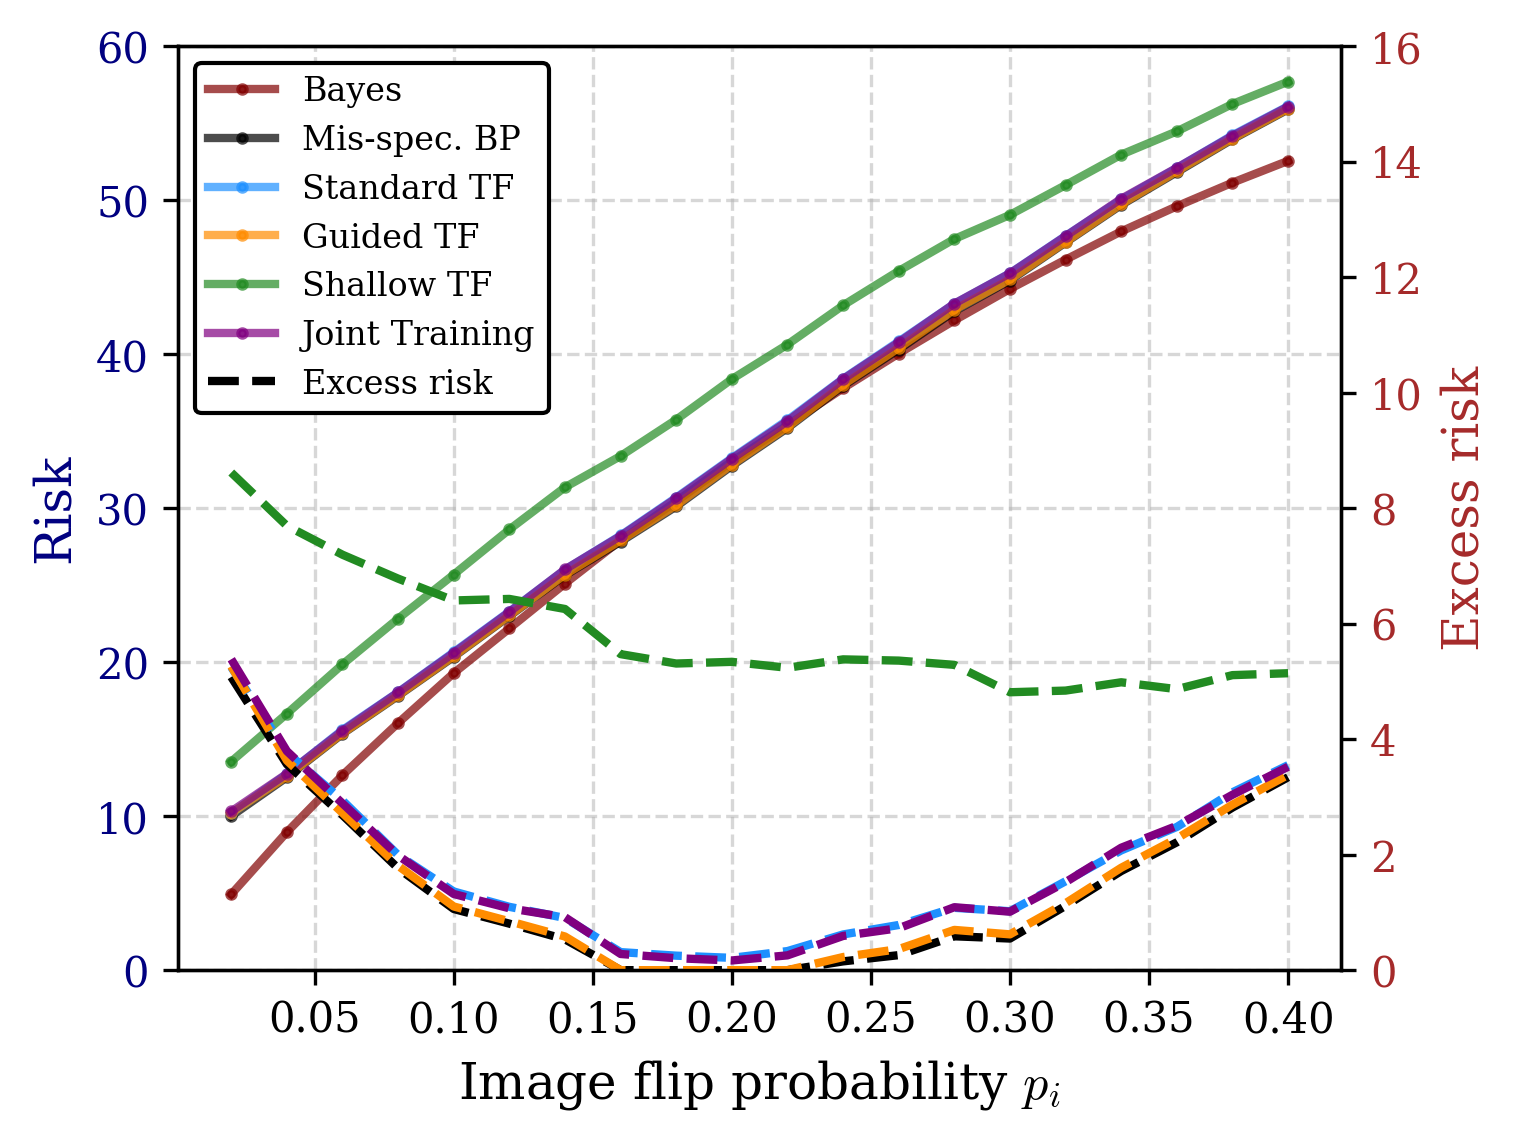

In [3]:
# Load the fixed-text CDM sweep and render the Fig. 9a PDF.
cdm_pt20 = load_ood_json("cdm-ood-pt20.json")
plot_modality_sweep(
    cdm_pt20,
    output_name="Fig9-a-CDM-ood.pdf",
    xlabel=r"Image flip probability $p_i$",
    risk_ylim=(0, 60),
    excess_ylim=(0, 16),
    legend_fontsize=8,
)

## Fig. 9b: VLM, fixed image probability

VLM keeps the image-side probability fixed at $p_i=0.20$ and sweeps the text-side probability $p_t$.

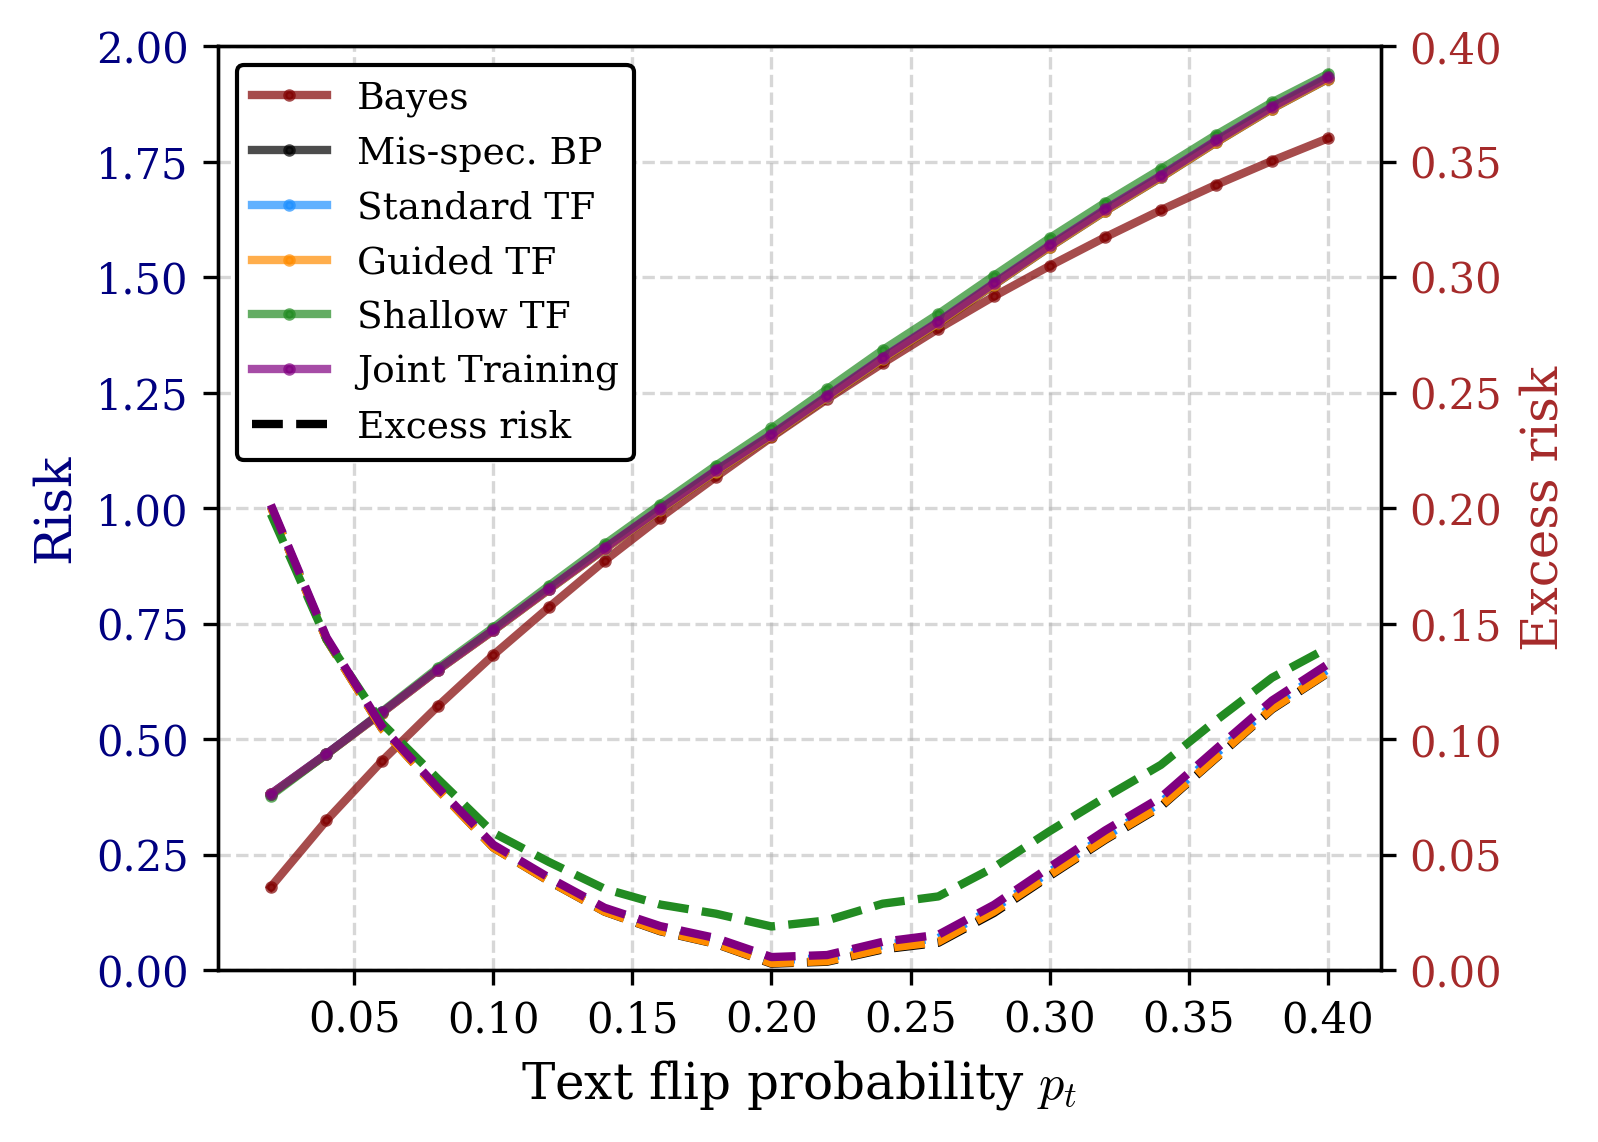

In [4]:
# Load the fixed-image VLM sweep and render the Fig. 9b PDF.
vlm_pi20 = load_ood_json("vlm-ood-pi20.json")
plot_modality_sweep(
    vlm_pi20,
    output_name="Fig9-b-VLM-ood.pdf",
    xlabel=r"Text flip probability $p_t$",
    risk_ylim=(0, 2),
    excess_ylim=(0, 0.4),
    legend_fontsize=9,
)